In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("/content/heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


***EDA***

In [4]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [5]:
df.shape

(920, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [7]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


EDA with data cleaning

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["num"].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


<Axes: xlabel='num'>

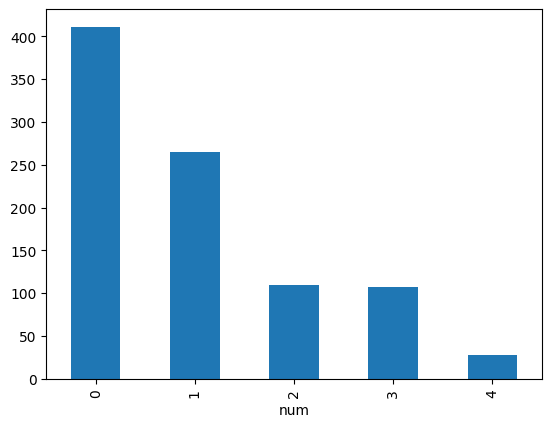

In [10]:
df["num"].value_counts().plot(kind="bar")

In [11]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [12]:
df.drop(columns=['ca', 'thal'], inplace=True)

In [13]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [14]:
cat_cols = ['fbs', 'restecg', 'exang', 'slope']

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [15]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


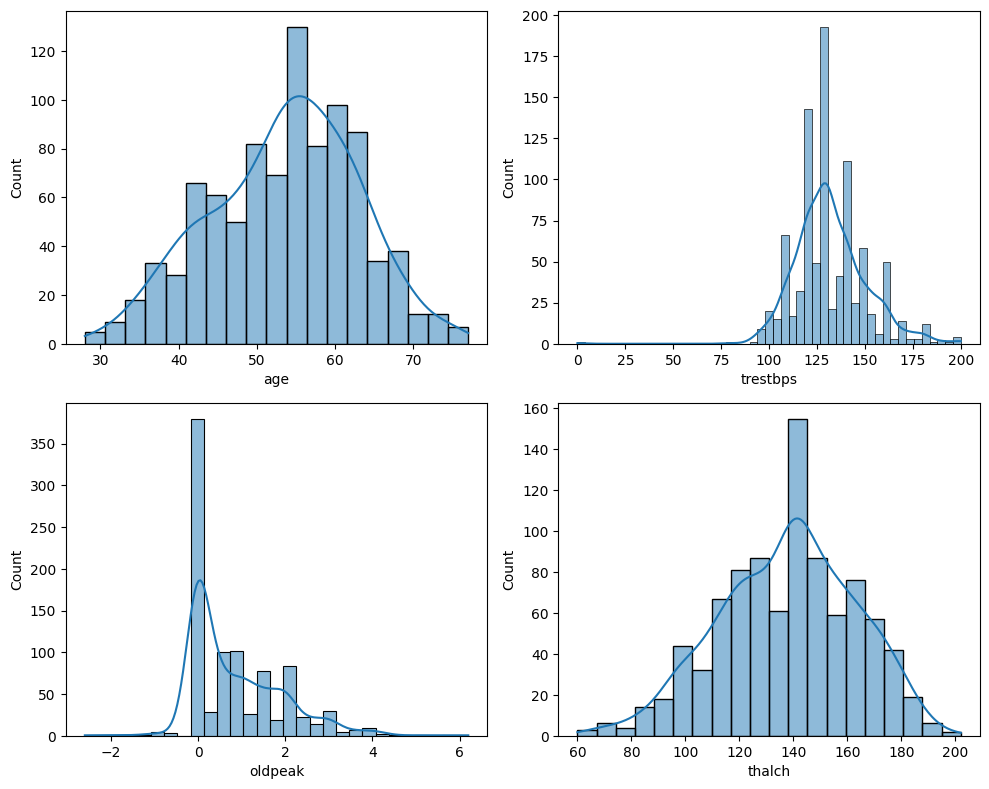

In [16]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
plt.figure(figsize=(10, 8)) # Added to create a figure before subplots
plotting('age',1)
plotting('trestbps',2)
plotting('oldpeak',3) # Changed from 5 to 3
plotting('thalch',4) # Changed from 4 to 4

plt.tight_layout()

In [17]:
cat_cols = ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope']

for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())


 sex
sex
Male      726
Female    194
Name: count, dtype: int64

 dataset
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

 cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

 fbs
fbs
False    782
True     138
Name: count, dtype: int64

 restecg
restecg
normal              553
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

 exang
exang
False    583
True     337
Name: count, dtype: int64

 slope
slope
flat           654
upsloping      203
downsloping     63
Name: count, dtype: int64


In [18]:
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [19]:
df['target'] = (df['num'] > 0).astype(int)

In [20]:
df.drop(columns=['num'], inplace=True)

In [21]:
df.drop(columns=['id'], inplace=True)

In [22]:
for col in ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope']:
    print("\n", col)
    print(df[col].value_counts())


 sex
sex
Male      726
Female    194
Name: count, dtype: int64

 dataset
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

 cp
cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

 fbs
fbs
False    782
True     138
Name: count, dtype: int64

 restecg
restecg
normal              553
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64

 exang
exang
False    583
True     337
Name: count, dtype: int64

 slope
slope
flat           654
upsloping      203
downsloping     63
Name: count, dtype: int64


In [23]:
print(df.columns.tolist())

['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'target']


In [24]:
df.head()

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,target
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,1
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,1
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0


In [25]:
df = pd.get_dummies(
    df,
    columns=['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope'],
    drop_first=True
)

In [26]:
df.head()

,age,trestbps,chol,thalch,oldpeak,target,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,0,True,False,False,False,False,False,True,True,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,1,True,False,False,False,False,False,False,False,False,False,True,True,False
2,67,120.0,229.0,129.0,2.6,1,True,False,False,False,False,False,False,False,False,False,True,True,False
3,37,130.0,250.0,187.0,3.5,0,True,False,False,False,False,True,False,False,True,False,False,False,False
4,41,130.0,204.0,172.0,1.4,0,False,False,False,False,True,False,False,False,False,False,False,False,True


In [27]:
print(df.isnull().sum().sum())

0


In [28]:
print(df.shape)

(920, 19)


In [29]:
# df = pd.get_dummies(
#     df,
#     columns=['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope'],
#     drop_first=True
# )

In [30]:
df.head()

,age,trestbps,chol,thalch,oldpeak,target,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,0,True,False,False,False,False,False,True,True,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,1,True,False,False,False,False,False,False,False,False,False,True,True,False
2,67,120.0,229.0,129.0,2.6,1,True,False,False,False,False,False,False,False,False,False,True,True,False
3,37,130.0,250.0,187.0,3.5,0,True,False,False,False,False,True,False,False,True,False,False,False,False
4,41,130.0,204.0,172.0,1.4,0,False,False,False,False,True,False,False,False,False,False,False,False,True


In [31]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [32]:
df.head()

,age,trestbps,chol,thalch,oldpeak,target,sex_Male,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping
0,63,145.0,233.0,150.0,2.3,0,1,0,0,0,0,0,1,1,0,0,0,0,0
1,67,160.0,286.0,108.0,1.5,1,1,0,0,0,0,0,0,0,0,0,1,1,0
2,67,120.0,229.0,129.0,2.6,1,1,0,0,0,0,0,0,0,0,0,1,1,0
3,37,130.0,250.0,187.0,3.5,0,1,0,0,0,0,1,0,0,1,0,0,0,0
4,41,130.0,204.0,172.0,1.4,0,0,0,0,0,1,0,0,0,0,0,0,0,1


In [33]:
X = df.drop('target', axis=1)
y = df['target']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(736, 18)
(184, 18)
(736,)
(184,)


In [36]:
print(X_train[num_cols].head())

     trestbps   chol  thalch  oldpeak
640     160.0    0.0   122.0      0.0
743     130.0    0.0   140.0      0.5
890     124.0  243.0   122.0      2.0
270     140.0  207.0   138.0      1.9
654     155.0    0.0    99.0      0.0


In [37]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [38]:
y_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8260869565217391


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        82
           1       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



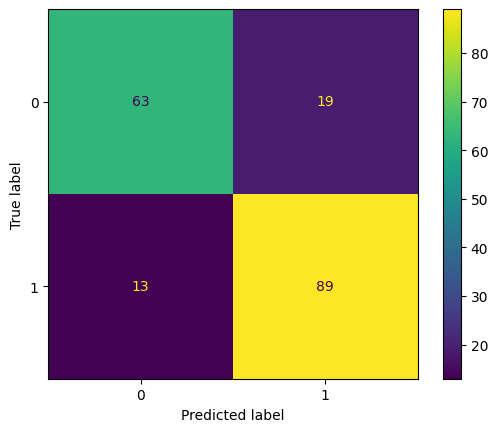

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8586956521739131
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        82
           1       0.86      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



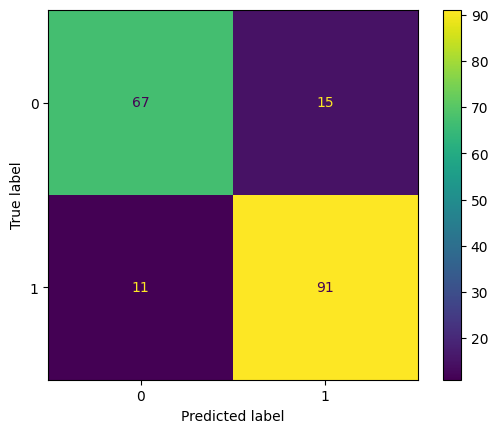

In [44]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

In [45]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7880434782608695
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        82
           1       0.79      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.78      0.78       184
weighted avg       0.79      0.79      0.79       184



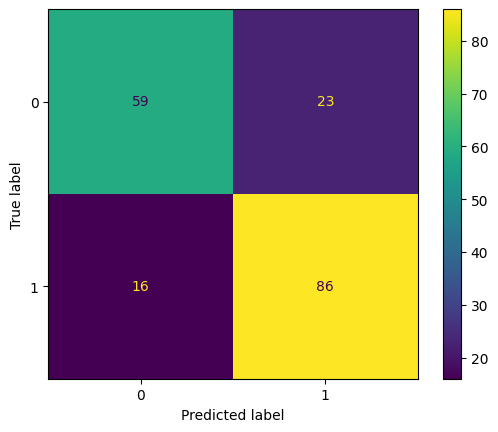

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, dt_pred)
plt.show()

In [48]:
from sklearn.metrics import roc_auc_score

lr_prob = model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("Logistic Regression AUC:",
      roc_auc_score(y_test, lr_prob))

print("Random Forest AUC:",
      roc_auc_score(y_test, rf_prob))

print("Decision Tree AUC:",
      roc_auc_score(y_test, dt_prob))

Logistic Regression AUC: 0.9207317073170731
Random Forest AUC: 0.9091343854615016
Decision Tree AUC: 0.781324725011956


In [49]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

chol                        0.138497
thalch                      0.134538
age                         0.127809
oldpeak                     0.119872
exang_True                  0.091566
trestbps                    0.082481
cp_atypical angina          0.064288
sex_Male                    0.044272
cp_non-anginal              0.031540
dataset_Switzerland         0.030305
dataset_Hungary             0.023567
restecg_normal              0.019171
fbs_True                    0.018043
slope_upsloping             0.017735
dataset_VA Long Beach       0.016286
slope_flat                  0.016228
restecg_st-t abnormality    0.012139
cp_typical angina           0.011664
dtype: float64


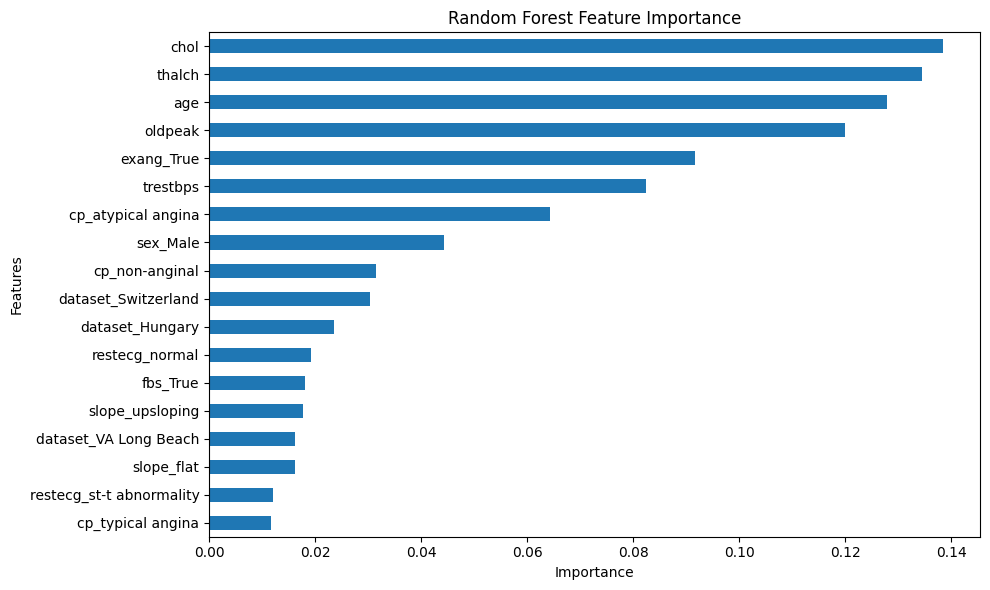

In [50]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind='barh')

plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')

plt.tight_layout()
plt.show()

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

chol                        0.138497
thalch                      0.134538
age                         0.127809
oldpeak                     0.119872
exang_True                  0.091566
trestbps                    0.082481
cp_atypical angina          0.064288
sex_Male                    0.044272
cp_non-anginal              0.031540
dataset_Switzerland         0.030305
dataset_Hungary             0.023567
restecg_normal              0.019171
fbs_True                    0.018043
slope_upsloping             0.017735
dataset_VA Long Beach       0.016286
slope_flat                  0.016228
restecg_st-t abnormality    0.012139
cp_typical angina           0.011664
dtype: float64


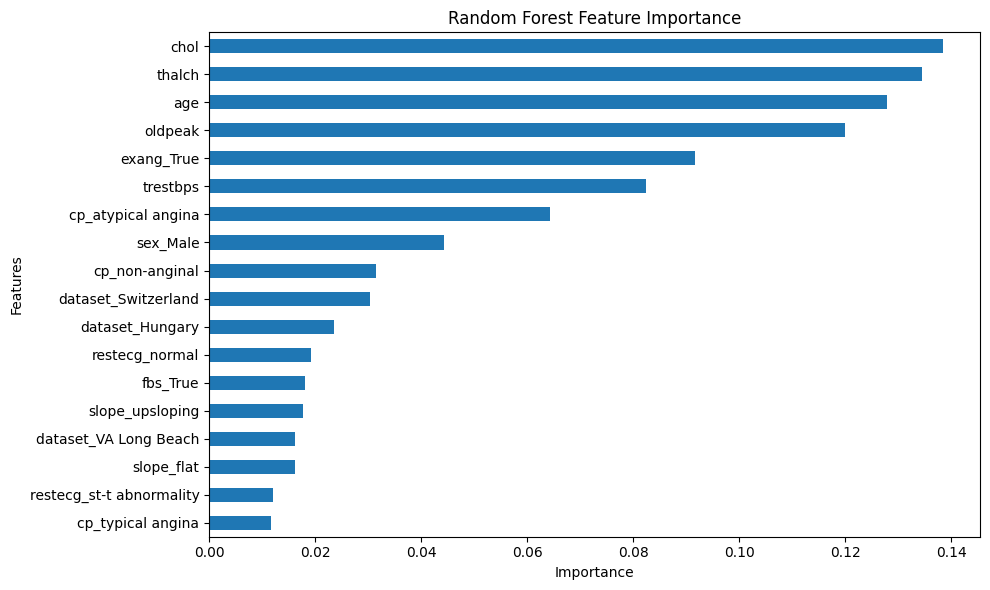

In [52]:
plt.figure(figsize=(10, 6))

importance.sort_values().plot(kind='barh')

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [53]:
dataset_cols = [col for col in X_train.columns if col.startswith('dataset_')]

X_train = X_train.drop(columns=dataset_cols)
X_test = X_test.drop(columns=dataset_cols)

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

# Re-train rf_model with the updated X_train (without dataset_cols)
# This step ensures the model is aligned with the current feature set of X_test
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.8478260869565217

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184

ROC-AUC: 0.914155906264945


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

# Re-running the RandomizedSearchCV to ensure completion
# This might take some time depending on the dataset size and parameters.
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc')

In [57]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation AUC:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 5}

Best Cross-Validation AUC:
0.8782557209928484


In [58]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

In [59]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_tuned))

Tuned Random Forest Accuracy: 0.8369565217391305

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        82
           1       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184

ROC-AUC: 0.9056671449067432


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

rf_cv = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf_cv,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("AUC scores for each fold:")
print(cv_scores)

print("\nMean AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

AUC scores for each fold:
[0.88888226 0.90937351 0.85485414 0.85270206 0.89401004]

Mean AUC: 0.8799644006941012
Standard Deviation: 0.022429732625936644


In [61]:
!pip install shap -q

In [62]:
import shap
import matplotlib.pyplot as plt

In [63]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

In [64]:
print(type(shap_values))

if isinstance(shap_values, list):
    print(len(shap_values))
    print(shap_values[0].shape)
    print(shap_values[1].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(184, 15, 2)


In [65]:
explainer_tuned = shap.TreeExplainer(best_rf)
shap_values_tuned = explainer_tuned.shap_values(X_test)

In [66]:
print(f"Shape of shap_values_tuned: {np.array(shap_values_tuned).shape}")
if isinstance(shap_values_tuned, list):
    print(f"Shape of shap_values_tuned[1]: {shap_values_tuned[1].shape}")

Shape of shap_values_tuned: (184, 15, 2)


In [67]:
print("X_test shape:", X_test.shape)
print("SHAP shape:", shap_values.shape)

X_test shape: (184, 15)
SHAP shape: (184, 15, 2)


In [68]:
print("X_test shape:", X_test.shape)
print("SHAP class 0 shape:", shap_values[0].shape)
print("SHAP class 1 shape:", shap_values[1].shape)

X_test shape: (184, 15)
SHAP class 0 shape: (15, 2)
SHAP class 1 shape: (15, 2)


In [69]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer(X_test)

print(shap_values.shape)

(184, 15, 2)


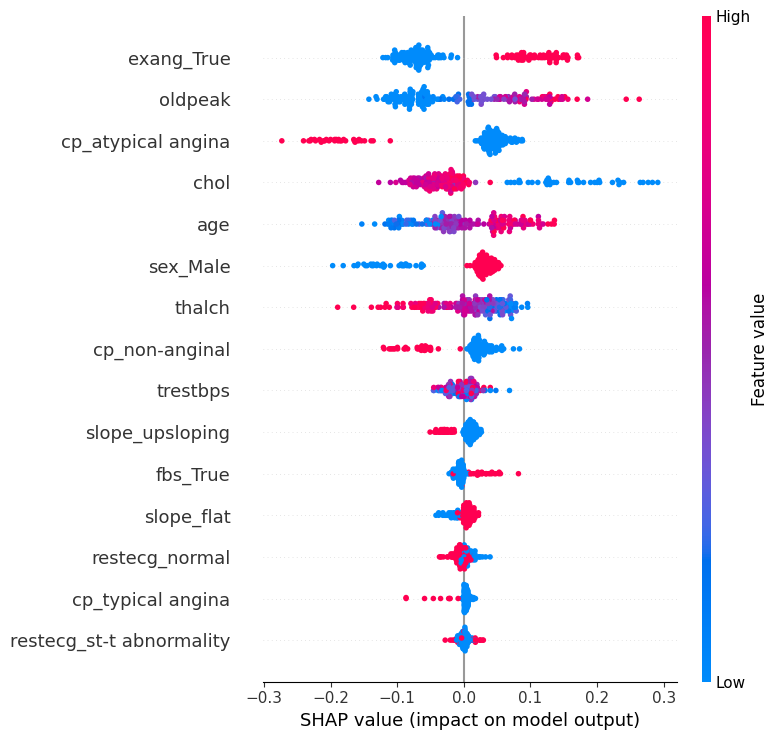

In [70]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [71]:
print("X_test:", X_test.shape)
print("SHAP:", shap_values.shape)

X_test: (184, 15)
SHAP: (184, 15, 2)


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [73]:
lr_prob = lr_model.predict_proba(X_test)[:, 1]

rf_prob = rf_model.predict_proba(X_test)[:, 1]

dt_prob = dt_model.predict_proba(X_test)[:, 1]

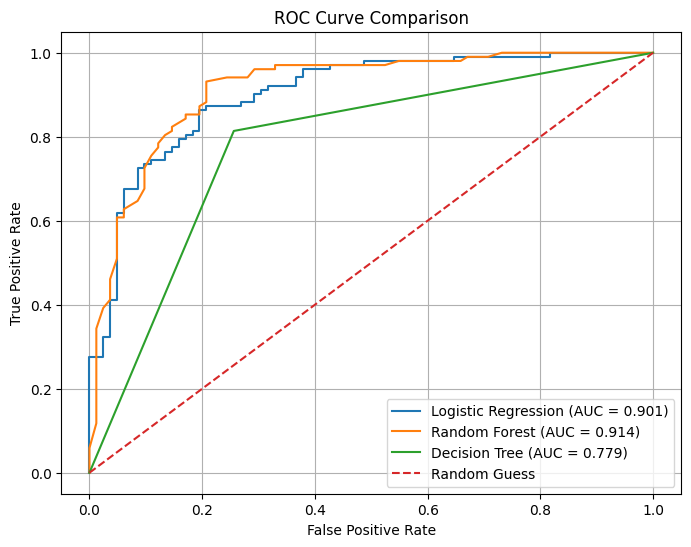

In [74]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

# Calculate AUC
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
dt_auc = roc_auc_score(y_test, dt_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr, lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    dt_fpr, dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

# Random guessing line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()
plt.show()

Confusion Matrix:
[[65 17]
 [11 91]]


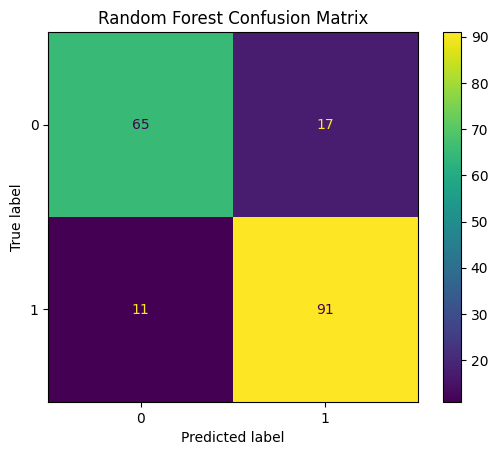

In [75]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

rf_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82        82
           1       0.84      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



In [77]:
import joblib

joblib.dump(rf_model, "heart_disease_random_forest.pkl")

print("Model saved successfully!")

Model saved successfully!


In [78]:
print(X_train.columns.tolist())

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping']


In [79]:
print(X_train.columns.tolist())

['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping']


In [80]:
import pandas as pd

def predict_heart_disease(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs,
    restecg,
    thalch,
    exang,
    oldpeak,
    slope
):
    data = {
        'age': age,
        'trestbps': trestbps,
        'chol': chol,
        'thalch': thalch,
        'oldpeak': oldpeak,
        'sex_Male': 1 if sex == 'Male' else 0,
        'cp_atypical angina': 1 if cp == 'atypical angina' else 0,
        'cp_non-anginal': 1 if cp == 'non-anginal' else 0,
        'cp_typical angina': 1 if cp == 'typical angina' else 0,
        'fbs_True': 1 if fbs else 0,
        'restecg_normal': 1 if restecg == 'normal' else 0,
        'restecg_st-t abnormality': 1 if restecg == 'st-t abnormality' else 0,
        'exang_True': 1 if exang else 0,
        'slope_flat': 1 if slope == 'flat' else 0,
        'slope_upsloping': 1 if slope == 'upsloping' else 0
    }

    input_data = pd.DataFrame([data])

    # Make sure columns are in exactly the same order
    input_data = input_data[X_train.columns]

    prediction = rf_model.predict(input_data)[0]
    probability = rf_model.predict_proba(input_data)[0][1]

    return prediction, probability

In [81]:
prediction, probability = predict_heart_disease(
    age=63,
    sex='Male',
    cp='typical angina',
    trestbps=145,
    chol=233,
    fbs=True,
    restecg='normal',
    thalch=150,
    exang=False,
    oldpeak=2.3,
    slope='downsloping'
)

print("Prediction:", prediction)
print("Probability:", round(probability * 100, 2), "%")

Prediction: 0
Probability: 35.0 %


In [82]:
import joblib

joblib.dump(rf_model, "heart_disease_rf.pkl")
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Model and feature columns saved!")

Model and feature columns saved!


In [83]:
import joblib

joblib.dump(rf_model, "heart_disease_rf.pkl")
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [84]:
import os

print(os.path.exists("heart_disease_rf.pkl"))
print(os.path.exists("feature_columns.pkl"))
print(os.path.exists("app.py"))

True
True
False


In [85]:
!pip install pyngrok -q

import os
import subprocess
import time
from pyngrok import ngrok
from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

# =========================================================
# GET NGROK AUTH TOKEN
# =========================================================

try:
    token = userdata.get("NGROK_AUTH_TOKEN")

    if token:
        ngrok.set_auth_token(token)
        print("✅ NGROK_AUTH_TOKEN successfully loaded.")
    else:
        print("⚠️ NGROK_AUTH_TOKEN is empty.")
        raise SystemExit

except SecretNotFoundError:
    print("❌ NGROK_AUTH_TOKEN not found in Colab Secrets.")
    print("Please add it using the 🔑 Secrets icon.")
    raise SystemExit

except Exception as e:
    print(f"❌ Error retrieving NGROK_AUTH_TOKEN: {e}")
    raise SystemExit


# =========================================================
# STOP OLD STREAMLIT PROCESSES
# =========================================================

os.system("pkill -f streamlit || true")

# Close old ngrok tunnels if any
try:
    ngrok.kill()
except Exception:
    pass


# =========================================================
# START STREAMLIT
# =========================================================

log_file = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.enableCORS",
        "false",
        "--server.enableXsrfProtection",
        "false"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT,
    preexec_fn=os.setsid
)

print("⏳ Starting Streamlit...")
time.sleep(7)


# =========================================================
# CREATE NGROK PUBLIC URL
# =========================================================

try:

    public_url = ngrok.connect(8501)

    print()
    print("==========================================")
    print("🚀 HEART HEALTH PREDICTOR IS RUNNING")
    print("==========================================")
    print()
    print("🌐 Public URL:")
    print(public_url)
    print()
    print("📄 Streamlit log:")
    print("/content/streamlit.log")
    print()

except Exception as e:

    print("❌ Could not create ngrok tunnel.")
    print("Error:", e)


✅ NGROK_AUTH_TOKEN successfully loaded.
⏳ Starting Streamlit...

🚀 HEART HEALTH PREDICTOR IS RUNNING

🌐 Public URL:
NgrokTunnel: "https://pushover-shorter-rehire.ngrok-free.dev" -> "http://localhost:8501"

📄 Streamlit log:
/content/streamlit.log



In [86]:
import time
time.sleep(3)
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-use1d2-1rxdyev2x6c7t-d.us-east1-2.prod.colab.dev


In [87]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > /content/streamlit.log 2>&1 &

In [88]:
import time
time.sleep(3)
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(8501)"))

https://8501-m-s-kkb-use1d2-1rxdyev2x6c7t-d.us-east1-2.prod.colab.dev


In [89]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 > streamlit.log 2>&1 &

In [90]:
from google.colab import userdata
userdata.get('NGROK_AUTH_TOKEN')

'3Hfi85ptNwl424bfTpPiER6WgUG_2jYEvNDxPeEawLg9cqiAp'

In [91]:
import os

print(os.listdir("/content"))

['.config', 'streamlit.log', 'heart_disease_uci.csv', 'feature_columns.pkl', 'heart_disease_rf.pkl', 'heart_disease_random_forest.pkl', 'drive', 'sample_data']


In [92]:
import os

print(os.path.exists("heart_disease_rf.pkl"))
print(os.path.exists("feature_columns.pkl"))
print(os.path.exists("app.py"))

True
True
False


In [93]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 30.3 MB/s eta 0:00:00


In [94]:
!streamlit run app.py &>/content/logs.txt &

In [95]:
!pip install streamlit pyngrok -q

In [96]:
from pyngrok import ngrok

ngrok.set_auth_token("3Hfi85ptNwl424bfTpPiER6WgUG_2jYEvNDxPeEawLg9cqiAp")

The `streamlit` library has been installed.

In [97]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print("Streamlit App URL:")
print(public_url)

Streamlit App URL:
NgrokTunnel: "https://pushover-shorter-rehire.ngrok-free.dev" -> "http://localhost:8501"


In [98]:
!streamlit run app.py --server.port 8501 > /content/streamlit.log 2>&1 &

In [99]:
!pkill -f streamlit

In [100]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [101]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print(url)

https://8501-m-s-kkb-use1d2-1rxdyev2x6c7t-d.us-east1-2.prod.colab.dev


In [102]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'streamlit.log', 'heart_disease_uci.csv', 'feature_columns.pkl', 'logs.txt', 'heart_disease_rf.pkl', 'heart_disease_random_forest.pkl', 'drive', 'sample_data']


In [103]:
from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

try:
    token = userdata.get('NGROK_AUTH_TOKEN')
    if token:
        print("✅ NGROK_AUTH_TOKEN is successfully set in Colab secrets.")
    else:
        print("⚠️ NGROK_AUTH_TOKEN is set, but its value might be empty.")
except SecretNotFoundError:
    print("❌ NGROK_AUTH_TOKEN is NOT set in Colab secrets.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

✅ NGROK_AUTH_TOKEN is successfully set in Colab secrets.


### Define and Launch Streamlit Application

First, I will define the content of the `app.py` file, which contains the Streamlit application logic. Then, I will write this content to a file named `app.py` in the current directory. Finally, I will launch the Streamlit application and expose it using `ngrok` to provide a public URL.

In [104]:
app_code = '''
import base64
import os
import textwrap
import joblib
import pandas as pd
import streamlit as st


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Heart Health Predictor",
    page_icon="❤️",
    layout="wide",
    initial_sidebar_state="collapsed",
)


# ============================================================
# FILE NAMES
# ============================================================

MODEL_FILE = "heart_disease_rf.pkl"
FEATURE_FILE = "feature_columns.pkl"
IMAGE_FILE = "WhatsApp Image 2026-07-30 at 23.30.29.jpeg"


# ============================================================
# CHECK REQUIRED FILES
# ============================================================

if not os.path.exists(MODEL_FILE):
    st.error(f"Model file not found: {MODEL_FILE}")
    st.stop()

if not os.path.exists(FEATURE_FILE):
    st.error(f"Feature file not found: {FEATURE_FILE}")
    st.stop()


# ============================================================
# LOAD MODEL AND FEATURES
# ============================================================

try:
    model = joblib.load(MODEL_FILE)
    feature_columns = joblib.load(FEATURE_FILE)
except Exception as error:
    st.error("Unable to load the model or feature file.")
    st.code(str(error))
    st.stop()


# ============================================================
# LOAD PROFILE IMAGE
# ============================================================

def get_image_base64(image_path):
    if not os.path.exists(image_path):
        return None

    try:
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")
    except Exception:
        return None


profile_image = get_image_base64(IMAGE_FILE)


# ============================================================
# CUSTOM CSS
# ============================================================

st.markdown(
    textwrap.dedent("""
    <style>
    .stApp {
        background: linear-gradient(135deg, #eef8ff 0%, #f8fbff 50%, #e7f4ff 100%);
    }

    .block-container {
        max-width: 1250px;
        padding-top: 2rem;
        padding-bottom: 2rem;
    }

    #MainMenu { visibility: hidden; }
    footer { visibility: hidden; }
    header { visibility: hidden; }

    .header-box {
        background: linear-gradient(135deg, #075985, #0284c7, #38bdf8);
        padding: 42px 30px;
        border-radius: 24px;
        text-align: center;
        color: white;
        margin-bottom: 25px;
        box-shadow: 0 12px 30px rgba(3, 105, 161, 0.22);
    }

    .header-title {
        font-size: 42px;
        font-weight: 800;
        margin: 0;
        color: white;
    }

    .header-subtitle {
        font-size: 18px;
        margin: 10px 0 5px;
        color: white;
    }

    .header-small {
        font-size: 15px;
        margin: 0;
        color: #e0f2fe;
    }

    .intro-box {
        background: white;
        padding: 25px 28px;
        border-radius: 20px;
        margin-bottom: 25px;
        border: 1px solid #dbeafe;
        box-shadow: 0 7px 22px rgba(15, 23, 42, 0.06);
    }

    .intro-title {
        color: #075985;
        font-size: 25px;
        font-weight: 750;
        margin-bottom: 12px;
    }

    .intro-text {
        color: #475569;
        line-height: 1.7;
        font-size: 16px;
        margin: 5px 0;
    }

    .section-header {
        background: linear-gradient(135deg, #f0f9ff, #e0f2fe);
        padding: 17px 20px;
        border-radius: 15px;
        margin-bottom: 18px;
        border-left: 5px solid #0284c7;
    }

    .section-title {
        margin: 0;
        color: #075985;
        font-size: 22px;
        font-weight: 750;
    }

    .section-subtitle {
        margin: 5px 0 0;
        color: #64748b;
        font-size: 14px;
    }

    .stTextInput label,
    .stNumberInput label,
    .stSelectbox label {
        color: #334155 !important;
        font-weight: 600 !important;
    }

    .stButton > button {
        width: 100%;
        background: linear-gradient(135deg, #075985, #0284c7);
        color: white;
        border: none;
        border-radius: 14px;
        padding: 14px 20px;
        font-size: 18px;
        font-weight: 700;
        box-shadow: 0 7px 18px rgba(2, 132, 199, 0.20);
    }

    .stButton > button:hover {
        background: linear-gradient(135deg, #0369a1, #0ea5e9);
        color: white;
    }

    .result-box {
        padding: 30px;
        border-radius: 22px;
        text-align: center;
        margin-top: 25px;
        margin-bottom: 25px;
        box-shadow: 0 10px 28px rgba(15, 23, 42, 0.08);
    }

    .result-risk {
        background: #fff1f2;
        border: 2px solid #fb7185;
    }

    .result-safe {
        background: #f0fdf4;
        border: 2px solid #4ade80;
    }

    .result-title {
        font-size: 28px;
        font-weight: 800;
        margin-bottom: 12px;
    }

    .percentage {
        font-size: 34px;
        font-weight: 800;
        color: #075985;
    }

    .result-description {
        color: #64748b;
        margin-top: 8px;
    }

    .info-card {
        background: white;
        padding: 28px;
        border-radius: 22px;
        margin-top: 30px;
        border: 1px solid #dbeafe;
        box-shadow: 0 8px 25px rgba(15, 23, 42, 0.06);
    }

    .info-title {
        color: #075985;
        font-size: 27px;
        font-weight: 800;
        margin-bottom: 15px;
    }

    .info-text {
        color: #475569;
        line-height: 1.8;
        font-size: 15px;
        margin: 8px 0;
    }

    .developer-card {
        background: white;
        padding: 32px;
        border-radius: 22px;
        text-align: center;
        margin-top: 30px;
        border: 1px solid #dbeafe;
        box-shadow: 0 8px 25px rgba(15, 23, 42, 0.07);
    }

    .developer-image {
        width: 130px;
        height: 130px;
        border-radius: 50%;
        object-fit: cover;
        border: 5px solid #0284c7;
        margin-bottom: 15px;
    }

    .developer-name {
        font-size: 25px;
        font-weight: 800;
        color: #075985;
        margin-top: 5px;
    }

    .developer-role {
        color: #64748b;
        font-size: 16px;
        margin: 5px 0;
    }

    .footer-box {
        text-align: center;
        margin-top: 40px;
        padding: 25px 15px;
        color: #64748b;
        border-top: 1px solid #cbd5e1;
        font-size: 14px;
        line-height: 1.8;
    }

    .footer-title {
        color: #075985;
        font-weight: 800;
        font-size: 17px;
    }

    @media (max-width: 768px) {
        .header-title { font-size: 30px; }
        .header-subtitle { font-size: 15px; }
        .intro-title { font-size: 21px; }
        .section-title { font-size: 19px; }
    }
    </style>
    """),
    unsafe_allow_html=True,
)


# ============================================================
# HEADER
# ============================================================

st.markdown(
    textwrap.dedent("""
    <div class="header-box">
        <div class="header-title">
            ❤️ Heart Health Predictor
        </div>
        <div class="header-subtitle">
            Machine Learning Based Heart Disease Risk Prediction System
        </div>
        <div class="header-small">
            Powered by Random Forest Classification
        </div>
    </div>
    """),
    unsafe_allow_html=True,
)


# ============================================================
# INTRODUCTION
# ============================================================

st.markdown(
    textwrap.dedent("""
    <div class="intro-box">
        <div class="intro-title">
            🩺 Welcome to Heart Health Predictor
        </div>
        <p class="intro-text">
            This application uses a trained Machine Learning model
            to estimate the likelihood of heart disease based on
            cardiovascular and clinical parameters.
        </p>
        <p class="intro-text">
            Enter the patient's information below and click
            <b>Check Heart Risk</b> to generate the prediction.
        </p>
    </div>
    """),
    unsafe_allow_html=True,
)


# ============================================================
# INPUT COLUMNS
# ============================================================

left_column, right_column = st.columns(2, gap="large")


# ============================================================
# PATIENT INFORMATION
# ============================================================

with left_column:
    st.markdown(
        textwrap.dedent("""
        <div class="section-header">
            <div class="section-title">
                👤 Patient Information
            </div>
            <div class="section-subtitle">
                Enter basic patient details
            </div>
        </div>
        """),
        unsafe_allow_html=True,
    )

    patient_name = st.text_input(
        "Patient Name", placeholder="Enter patient name"
    )
    age = st.number_input("Age", min_value=1, max_value=120, value=50, step=1)
    sex = st.selectbox("Sex", ["Male", "Female"])
    cp = st.selectbox(
        "Chest Pain Type",
        ["typical angina", "atypical angina", "non-anginal", "asymptomatic"],
    )
    fbs = st.selectbox(
        "Fasting Blood Sugar > 120 mg/dl",
        [False, True],
        format_func=lambda x: "Yes" if x else "No",
    )
    restecg = st.selectbox(
        "Resting ECG", ["normal", "st-t abnormality", "lv hypertrophy"]
    )


# ============================================================
# HEART PARAMETERS
# ============================================================

with right_column:
    st.markdown(
        textwrap.dedent("""
        <div class="section-header">
            <div class="section-title">
                ❤️ Heart Parameters
            </div>
            <div class="section-subtitle">
                Enter cardiovascular measurements
            </div>
        </div>
        """),
        unsafe_allow_html=True,
    )

    trestbps = st.number_input(
        "Resting Blood Pressure", min_value=50, max_value=250, value=120, step=1
    )
    chol = st.number_input(
        "Cholesterol", min_value=50, max_value=700, value=200, step=1
    )
    thalch = st.number_input(
        "Maximum Heart Rate", min_value=50, max_value=250, value=150, step=1
    )
    exang = st.selectbox(
        "Exercise Induced Angina",
        [False, True],
        format_func=lambda x: "Yes" if x else "No",
    )
    oldpeak = st.number_input(
        "Oldpeak", min_value=0.0, max_value=10.0, value=1.0, step=0.1
    )
    slope = st.selectbox(
        "ST Segment Slope", ["downsloping", "flat", "upsloping"]
    )


# ============================================================
# PREDICTION BUTTON
# ============================================================

st.markdown("<br>", unsafe_allow_html=True)

predict_button = st.button("🔍 CHECK HEART RISK")


# ============================================================
# PREDICTION
# ============================================================

if predict_button:
    if patient_name.strip() == "":
        st.error("⚠️ Please enter the patient name.")
        st.stop()

    data = {
        "age": age,
        "trestbps": trestbps,
        "chol": chol,
        "thalch": thalch,
        "oldpeak": oldpeak,
        "sex_Male": 1 if sex == "Male" else 0,
        "cp_atypical angina": 1 if cp == "atypical angina" else 0,
        "cp_non-anginal": 1 if cp == "non-anginal" else 0,
        "cp_typical angina": 1 if cp == "typical angina" else 0,
        "fbs_True": 1 if fbs else 0,
        "restecg_normal": 1 if restecg == "normal" else 0,
        "restecg_st-t abnormality": 1 if restecg == "st-t abnormality" else 0,
        "exang_True": 1 if exang else 0,
        "slope_flat": 1 if slope == "flat" else 0,
        "slope_upsloping": 1 if slope == "upsloping" else 0,
    }

    input_data = pd.DataFrame([data])

    missing_features = [
        feature for feature in feature_columns if feature not in input_data.columns
    ]

    if missing_features:
        st.error("The following features are missing from the input:")
        st.write(missing_features)
        st.stop()

    input_data = input_data[feature_columns]

    try:
        prediction = model.predict(input_data)[0]
        probabilities = model.predict_proba(input_data)[0]

        if hasattr(model, "classes_"):
            classes = list(model.classes_)
            if 1 in classes:
                positive_index = classes.index(1)
                probability = probabilities[positive_index]
            else:
                probability = probabilities[-1]
        else:
            probability = probabilities[-1]

        probability_percent = probability * 100

    except Exception as error:
        st.error("Prediction failed.")
        st.code(str(error))
        st.stop()

    st.markdown("## 📊 Prediction Result")

    if prediction == 1:
        result_text = "Higher Likelihood of Heart Disease"
        st.markdown(
            f"""
            <div class="result-box result-risk">
                <div class="result-title">
                    ⚠️ Higher Likelihood of Heart Disease
                </div>
                <div class="percentage">
                    {probability_percent:.2f}%
                </div>
                <div class="result-description">
                    Estimated probability of the positive class
                </div>
            </div>
            """,
            unsafe_allow_html=True,
        )
    else:
        result_text = "Lower Likelihood of Heart Disease"
        st.markdown(
            f"""
            <div class="result-box result-safe">
                <div class="result-title">
                    🟢 Lower Likelihood of Heart Disease
                </div>
                <div class="percentage">
                    {probability_percent:.2f}%
                </div>
                <div class="result-description">
                    Estimated probability of the positive class
                </div>
            </div>
            """,
            unsafe_allow_html=True,
        )

    st.markdown("### 📈 Heart Disease Probability")
    st.progress(min(max(float(probability), 0.0), 1.0))

    st.markdown(
        f"""
        <div style="
            text-align: center;
            font-size: 30px;
            font-weight: 800;
            color: #075985;
            margin: 15px;
        ">
            {probability_percent:.2f}%
        </div>
        """,
        unsafe_allow_html=True,
    )

    st.markdown("### 📋 Patient Summary")

    summary = pd.DataFrame(
        {
            "Parameter": [
                "Patient Name",
                "Age",
                "Sex",
                "Chest Pain",
                "Fasting Blood Sugar > 120",
                "Resting ECG",
                "Blood Pressure",
                "Cholesterol",
                "Maximum Heart Rate",
                "Exercise Angina",
                "Oldpeak",
                "Slope",
                "Result",
                "Heart Disease Probability",
            ],
            "Value": [
                patient_name,
                age,
                sex,
                cp,
                "Yes" if fbs else "No",
                restecg,
                trestbps,
                chol,
                thalch,
                "Yes" if exang else "No",
                oldpeak,
                slope,
                result_text,
                f"{probability_percent:.2f}%",
            ],
        }
    )

    st.dataframe(summary, use_container_width=True, hide_index=True)

    st.markdown("### 💡 Interpretation")

    if prediction == 1:
        st.warning(
            f"""
            The Random Forest model predicts a
            **higher likelihood of the positive class**.

            Predicted probability:
            **{probability_percent:.2f}%**
            """
        )
    else:
        st.success(
            f"""
            The Random Forest model predicts a
            **lower likelihood of the positive class**.

            Predicted probability:
            **{probability_percent:.2f}%**
            """
        )

    st.warning(
        """
        ⚠️ **Important:** This application is developed for
        academic and research purposes only.

        The prediction generated by this machine-learning model
        is **not a medical diagnosis** and should not replace
        professional medical advice.
        """
    )


# ============================================================
# ABOUT PROJECT
# ============================================================

st.markdown(
    textwrap.dedent("""
    <div class="info-card">
        <div class="info-title">
            🧠 About This Project
        </div>
        <p class="info-text">
            The <b>Heart Health Predictor</b> is an academic
            machine-learning project designed to demonstrate how
            healthcare-related patient data can be used for
            predictive analysis.
        </p>
        <p class="info-text">
            The system uses a
            <b>Random Forest Classification Model</b>
            trained on heart disease-related data.
        </p>
        <p class="info-text">
            The model uses parameters such as age,
            blood pressure, cholesterol, maximum heart rate,
            chest pain type and exercise-induced angina.
        </p>
        <p class="info-text">
            The project workflow includes data preprocessing,
            missing-value handling, categorical encoding,
            model training, model evaluation, ROC-AUC analysis,
            feature importance and SHAP-based interpretation.
        </p>
        <p class="info-text">
            The purpose of this project is to demonstrate the
            application of <b>Machine Learning in healthcare
            data analysis</b>.
        </p>
    </div>
    """),
    unsafe_allow_html=True,
)


# ============================================================
# DEVELOPER
# ============================================================

if profile_image:
    st.markdown(
        f"""
        <div class="developer-card">
            <img
                class="developer-image"
                src="data:image/jpeg;base64,{profile_image}"
            >
            <div class="developer-name">
                Developed by Subhanshu Yagik
            </div>
            <p class="developer-role">
                B.Tech Data Science Student
            </p>
            <p class="developer-role">
                Academic Machine Learning Project
            </p>
        </div>
        """,
        unsafe_allow_html=True,
    )
else:
    st.markdown(
        """
        <div class="developer-card">
            <div class="developer-name">
                Developed by Subhanshu Yagik
            </div>
            <p class="developer-role">
                B.Tech Data Science Student
            </p>
            <p class="developer-role">
                Academic Machine Learning Project
            </p>
        </div>
        """,
        unsafe_allow_html=True,
    )


# ============================================================
# FOOTER
# ============================================================

st.markdown(
    textwrap.dedent("""
    <div class="footer-box">
        <div class="footer-title">
            ❤️ Heart Health Predictor
        </div>
        <div>
            Random Forest Machine Learning Model
        </div>
        <div>
            Developed by <b>Subhanshu Yagik</b>
        </div>
        <div>
            Academic & Research Project
        </div>
    </div>
    """),
    unsafe_allow_html=True,
)
'''

In [105]:
# Write the app_code to app.py
with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")

app.py created successfully!


In [106]:
import os
import subprocess
import time
from pyngrok import ngrok
from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

# =========================================================
# GET NGROK AUTH TOKEN
# =========================================================

try:
    token = userdata.get("NGROK_AUTH_TOKEN")

    if token:
        ngrok.set_auth_token(token)
        print("✅ NGROK_AUTH_TOKEN successfully loaded.")
    else:
        print("⚠️ NGROK_AUTH_TOKEN is empty.")
        raise SystemExit

except SecretNotFoundError:
    print("❌ NGROK_AUTH_TOKEN not found in Colab Secrets.")
    print("Please add it using the 🔑 Secrets icon.")
    raise SystemExit

except Exception as e:
    print(f"❌ Error retrieving NGROK_AUTH_TOKEN: {e}")
    raise SystemExit


# =========================================================
# STOP OLD STREAMLIT PROCESSES
# =========================================================

os.system("pkill -f streamlit || true")

# Close old ngrok tunnels if any
try:
    ngrok.kill()
except Exception:
    pass


# =========================================================
# START STREAMLIT
# =========================================================

log_file = open("/content/streamlit.log", "w")

process = subprocess.Popen(
    [
        "python",
        "-m",
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0",
        "--server.enableCORS",
        "false",
        "--server.enableXsrfProtection",
        "false"
    ],
    stdout=log_file,
    stderr=subprocess.STDOUT,
    preexec_fn=os.setsid
)

print("⏳ Starting Streamlit...")
time.sleep(7)


# =========================================================
# CREATE NGROK PUBLIC URL
# =========================================================

try:

    public_url = ngrok.connect(8501)

    print()
    print("==========================================")
    print("🚀 HEART HEALTH PREDICTOR IS RUNNING")
    print("==========================================")
    print()
    print("🌐 Public URL:")
    print(public_url)
    print()
    print("📄 Streamlit log:")
    print("/content/streamlit.log")
    print()

except Exception as e:

    print("❌ Could not create ngrok tunnel.")
    print("Error:", e)

✅ NGROK_AUTH_TOKEN successfully loaded.
⏳ Starting Streamlit...

🚀 HEART HEALTH PREDICTOR IS RUNNING

🌐 Public URL:
NgrokTunnel: "https://pushover-shorter-rehire.ngrok-free.dev" -> "http://localhost:8501"

📄 Streamlit log:
/content/streamlit.log



In [ ]:
!ls

app.py	feature_columns.pkl		 heart_disease_rf.pkl  sample_data
drive	heart_disease_random_forest.pkl  logs.txt	       streamlit.log


In [ ]:
!git config --global user.name "Subhanshyagik"
!git config --global user.email "yagiksubhanshu74@gmail.com"

In [ ]:
%cd /content/heart-disease-prediction

[Errno 2] No such file or directory: '/content/heart-disease-prediction'
/content


In [ ]:
import os
if not os.path.exists('/content/heart-disease-prediction'):
    os.makedirs('/content/heart-disease-prediction')
get_ipython().system('cd /content/heart-disease-prediction')

In [ ]:
!ls

app.py		     heart-disease-prediction	      logs.txt
drive		     heart_disease_random_forest.pkl  sample_data
feature_columns.pkl  heart_disease_rf.pkl	      streamlit.log


In [ ]:
get_ipython().system('git init')

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [ ]:
%%writefile .gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
.env
venv/
.venv/

Writing .gitignore


In [ ]:
!git status

On branch master

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	.gitignore
	app.py
	drive/
	feature_columns.pkl
	heart_disease_random_forest.pkl
	heart_disease_rf.pkl
	logs.txt
	sample_data/
	streamlit.log

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
!git add .

error: open("drive/MyDrive/CSE_Mini Project Synopsis_Format 2026_27 (2).gdoc"): Operation not supported
error: unable to index file 'drive/MyDrive/CSE_Mini Project Synopsis_Format 2026_27 (2).gdoc'
fatal: adding files failed
